# Website Traffic Analysis — Alfido Tech
**Task 3 of 3 — Internship Data Analytics Program**

**Dataset:** Music smart-link traffic events — `traffic.csv`. Each row is a single traffic event (a pageview, preview, or click) recorded on a music smart-link page, with the visitor's country/city and the artist/track/album/link being viewed.

**Goal:** Analyze website (smart-link) traffic to understand visitor volume and trend, the pageview → click conversion funnel, geographic patterns, and top-performing content, and provide actionable recommendations for Alfido Tech.

**Contents**
1. Setup & Data Loading
2. Data Cleaning
3. Summary Statistics & Data Types
4. Feature Engineering
5. Traffic Trend Analysis
6. Conversion Funnel Analysis
7. Geographic Analysis
8. Content Performance (Artists, Tracks, Links)
9. Key Findings & 5 Actionable Recommendations


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
EVENT_COLORS = {"pageview": "#2E5EAA", "preview": "#F2A541", "click": "#3FA796"}

df = pd.read_csv("traffic.csv")
print("Shape:", df.shape)
df.head()


Shape: (226278, 9)


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   event    226278 non-null  str  
 1   date     226278 non-null  str  
 2   country  226267 non-null  str  
 3   city     226267 non-null  str  
 4   artist   226241 non-null  str  
 5   album    226273 non-null  str  
 6   track    226273 non-null  str  
 7   isrc     219157 non-null  str  
 8   linkid   226278 non-null  str  
dtypes: str(9)
memory usage: 15.5 MB


## 2. Data Cleaning

This dataset has no user or session ID — each row is one atomic traffic event (a pageview, preview, or click). That matters for how we interpret a few things below.

**Checks performed:**
- **Duplicate rows:** ~46% of rows are exact duplicates of another row. We verified this is *not* a data quality problem: with no user ID, a popular track's link page being viewed by hundreds of different, anonymous visitors from the same city on the same day produces identical-looking rows. For example, Tesher's "Jalebi Baby" link was viewed 729 times from Jeddah, Saudi Arabia on 2021-08-21 alone — verified by grouping on every column, which showed real repeat counts well into the hundreds for popular links. We therefore **do not drop duplicate rows** — doing so would silently delete real traffic volume.
- **Missing values:** `country`/`city`/`artist`/`track` are missing for a small number of rows (11–37 rows each, out of 226K) — dropped, since they can't be attributed to any dimension used in this analysis. `isrc` (an industry recording code) is missing for ~3% of rows but isn't used here, so it's left as-is.
- **"Unknown" city:** ~16,661 rows have `city = "Unknown"` — this is a legitimate category (geolocation blocked or undetermined), not missing data, and is excluded only from the city-level ranking (Section 7) since it isn't an actual city.
- **Date parsing:** `date` converted to datetime; the data spans exactly one week (2021-08-19 to 2021-08-25).


In [3]:
df["date"] = pd.to_datetime(df["date"])

# Verify the duplicate-row explanation: group on every column and check the
# largest repeat counts for a well-known popular link
dupe_check = df.groupby(list(df.columns)).size().sort_values(ascending=False)
print("Largest identical-row repeat counts (verifying duplicates = real repeat traffic):")
print(dupe_check.head(3))

print("\nExact duplicate rows:", df.duplicated().sum(), f"({df.duplicated().mean():.1%} of all rows)")

print("\nMissing values:\n", df.isna().sum())
print("\n'Unknown' city rows:", (df["city"] == "Unknown").sum())

before = len(df)
df = df.dropna(subset=["country", "city", "artist", "track"])
print(f"\nDropped {before - len(df)} rows missing country/city/artist/track")

print(f"\nClean dataset: {len(df):,} events, {df['country'].nunique()} countries, "
      f"{df['city'].nunique():,} cities, {df['artist'].nunique():,} artists, "
      f"{df['track'].nunique():,} tracks, {df['linkid'].nunique():,} links")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()} (7 days)")


Largest identical-row repeat counts (verifying duplicates = real repeat traffic):
event     date        country       city    artist  album        track        isrc          linkid                              
pageview  2021-08-21  Saudi Arabia  Jeddah  Tesher  Jalebi Baby  Jalebi Baby  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8    729
          2021-08-20  Saudi Arabia  Jeddah  Tesher  Jalebi Baby  Jalebi Baby  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8    689
          2021-08-21  Saudi Arabia  Riyadh  Tesher  Jalebi Baby  Jalebi Baby  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8    546
dtype: int64



Exact duplicate rows: 103711 (45.8% of all rows)

Missing values:
 event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

'Unknown' city rows: 16661

Dropped 48 rows missing country/city/artist/track

Clean dataset: 226,230 events, 211 countries, 11,992 cities, 2,419 artists, 3,547 tracks, 3,822 links
Date range: 2021-08-19 to 2021-08-25 (7 days)


## 3. Summary Statistics & Data Types

In [4]:
df.dtypes

event                 str
date       datetime64[us]
country               str
city                  str
artist                str
album                 str
track                 str
isrc                  str
linkid                str
dtype: object

In [5]:
print("Event type counts:")
print(df["event"].value_counts())
print("\nEvent type %:")
print((df["event"].value_counts(normalize=True) * 100).round(1))


Event type counts:


event
pageview    141980
click        55720
preview      28530
Name: count, dtype: int64

Event type %:
event
pageview    62.8
click       24.6
preview     12.6
Name: proportion, dtype: float64


In [6]:
for col in ["country", "artist"]:
    print(f"\n{col}: {df[col].nunique()} unique values, mode = {df[col].mode()[0]!r}")



country: 211 unique values, mode = 'Saudi Arabia'

artist: 2419 unique values, mode = 'Tesher'


## 4. Feature Engineering

In [7]:
df["weekday"] = df["date"].dt.day_name()
df[["date", "weekday", "event"]].head()


,date,weekday,event
0,2021-08-21,Saturday,click
1,2021-08-21,Saturday,click
2,2021-08-21,Saturday,click
3,2021-08-21,Saturday,click
4,2021-08-21,Saturday,click


In [8]:
def k_fmt(x, pos):
    if x >= 1e6: return f"{x/1e6:.1f}M"
    if x >= 1e3: return f"{x/1e3:.0f}K"
    return f"{x:.0f}"


## 5. Traffic Trend Analysis

event       click  pageview  preview
date                                
2021-08-19   9203     22356     3788
2021-08-20   8501     21368     4222
2021-08-21   8071     21349     4663
2021-08-22   7854     20430     4349
2021-08-23   7314     18645     3846
2021-08-24   7301     18685     3840
2021-08-25   7476     19147     3822


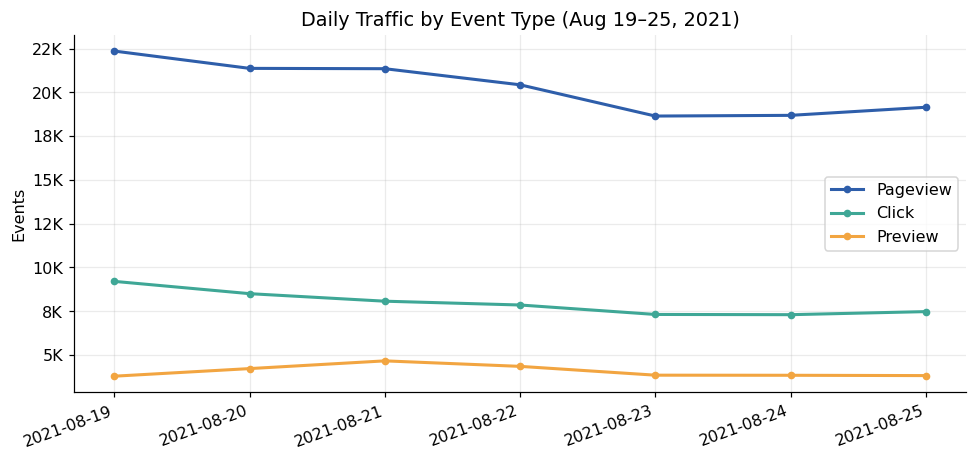

In [9]:
daily = df.groupby([df["date"].dt.date, "event"]).size().unstack(fill_value=0)
daily.index = pd.to_datetime(daily.index)
print(daily)

fig, ax = plt.subplots(figsize=(9, 4.3))
for ev in ["pageview", "click", "preview"]:
    ax.plot(daily.index, daily[ev], marker="o", markersize=4, linewidth=2, color=EVENT_COLORS[ev], label=ev.capitalize())
ax.set_title("Daily Traffic by Event Type (Aug 19–25, 2021)")
ax.set_ylabel("Events")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(k_fmt))
ax.legend()
fig.autofmt_xdate(rotation=20)
plt.tight_layout()
plt.show()


In [10]:
daily_total = df.groupby(df["date"].dt.date).size()
pct_change = (daily_total.iloc[-1] / daily_total.iloc[0] - 1) * 100
print(f"Total daily traffic, first day: {daily_total.iloc[0]:,}")
print(f"Total daily traffic, last day: {daily_total.iloc[-1]:,}")
print(f"Change over the week: {pct_change:.1f}%")


Total daily traffic, first day: 35,347


Total daily traffic, last day: 30,445
Change over the week: -13.9%


**Finding:** total traffic declined steadily across the week, from ~35,300 events on Aug 19 down to ~30,400 on Aug 25 — a 13.9% drop. Pageviews and clicks both trend downward in lockstep, while previews stay comparatively flat, suggesting this is a broad traffic decline (e.g. a viral moment cooling off) rather than a change in visitor behavior once they land.

## 6. Conversion Funnel Analysis

`pageview` is a visit to the smart-link page. From there, a visitor can `preview` (play a short audio preview) and/or `click` (click through to a streaming platform). These aren't strictly sequential steps for every visitor, but pageview is always the entry point, so we treat it as the funnel's top.


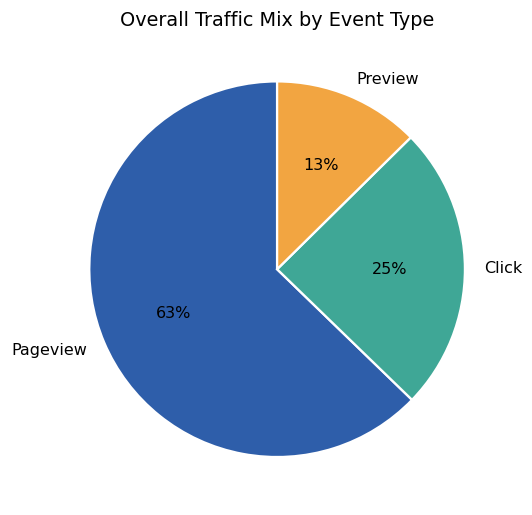

In [11]:
event_counts = df["event"].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(event_counts.values, labels=[e.capitalize() for e in event_counts.index], autopct="%1.0f%%", startangle=90,
       colors=[EVENT_COLORS[e] for e in event_counts.index], wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Overall Traffic Mix by Event Type")
plt.tight_layout()
plt.show()


Pageviews: 141,980
Previews: 28,530 (20.1% of pageviews)
Clicks: 55,720 (39.2% of pageviews)


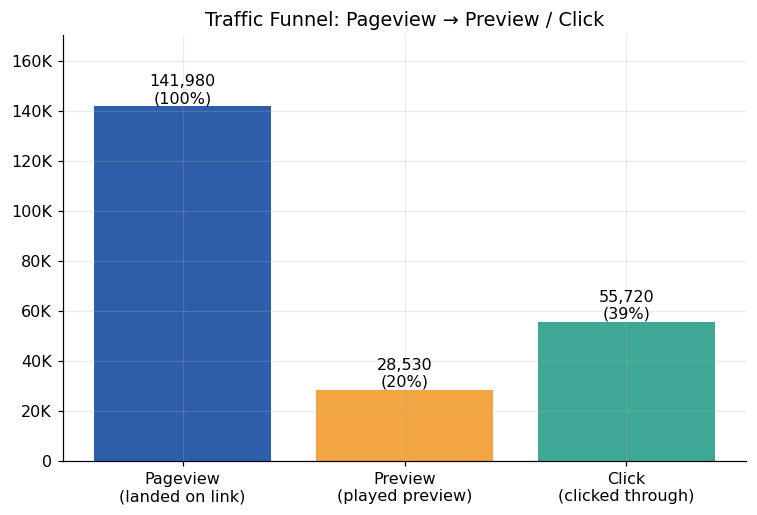

In [12]:
total_pageviews = event_counts["pageview"]
total_previews = event_counts["preview"]
total_clicks = event_counts["click"]
overall_ctr = total_clicks / total_pageviews
overall_preview_rate = total_previews / total_pageviews

print(f"Pageviews: {total_pageviews:,}")
print(f"Previews: {total_previews:,} ({overall_preview_rate:.1%} of pageviews)")
print(f"Clicks: {total_clicks:,} ({overall_ctr:.1%} of pageviews)")

fig, ax = plt.subplots(figsize=(7, 4.8))
funnel_vals = [total_pageviews, total_previews, total_clicks]
funnel_labels = ["Pageview\n(landed on link)", "Preview\n(played preview)", "Click\n(clicked through)"]
bars = ax.bar(funnel_labels, funnel_vals, color=[EVENT_COLORS["pageview"], EVENT_COLORS["preview"], EVENT_COLORS["click"]])
ax.set_title("Traffic Funnel: Pageview → Preview / Click")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(k_fmt))
for b, v in zip(bars, funnel_vals):
    ax.annotate(f"{v:,}\n({v/funnel_vals[0]*100:.0f}%)", (b.get_x()+b.get_width()/2, b.get_height()), ha="center", va="bottom")
ax.set_ylim(0, funnel_vals[0]*1.2)
plt.tight_layout()
plt.show()


**Finding:** 39.2% of all pageviews convert directly to a click-through — a strong headline conversion rate for this kind of link page. Only 20.1% of visitors play a preview first, meaning the large majority of clicks come from visitors who already knew what they wanted to hear, likely arriving via a direct share or promotion rather than discovering the track on the page itself.

## 7. Geographic Analysis

event                 click  pageview  preview  total
country                                              
Saudi Arabia           9495     28873     8966  47334
India                 11609     27286     4097  42992
United States          9523     20816     2186  32525
France                 4054      9674     1933  15661
Iraq                   1836      4897     1527   8260
United Kingdom         1517      3845      608   5970
Pakistan               1653      3212      779   5644
Germany                1224      3140      428   4792
United Arab Emirates    766      2335      601   3702
Turkey                  654      2462      398   3514


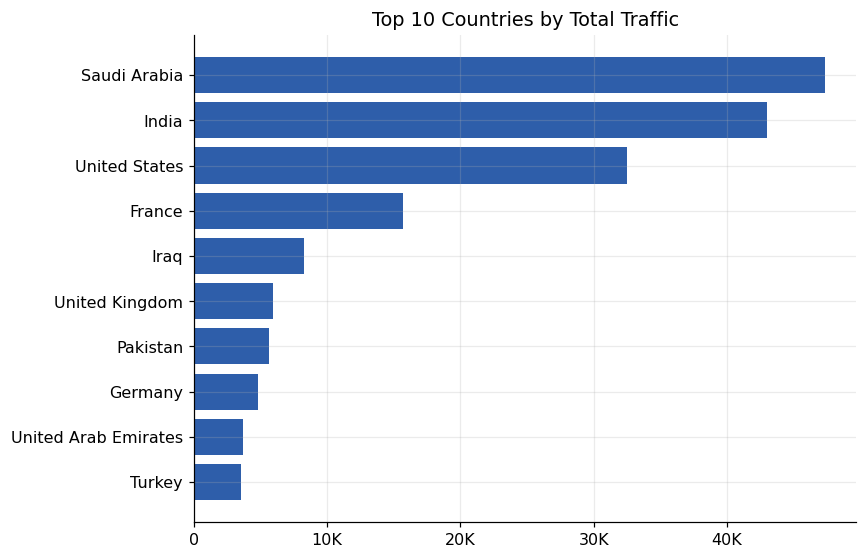

In [13]:
country_events = df.groupby("country")["event"].value_counts().unstack(fill_value=0)
country_events["total"] = country_events.sum(axis=1)
top_country = country_events.sort_values("total", ascending=False).head(10)
print(top_country)

fig, ax = plt.subplots(figsize=(8, 5.2))
plot_data = top_country.sort_values("total")
ax.barh(plot_data.index, plot_data["total"], color="#2E5EAA")
ax.set_title("Top 10 Countries by Total Traffic")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(k_fmt))
plt.tight_layout()
plt.show()


**Finding:** Saudi Arabia (47,334 events) and India (42,992 events) are by far the largest traffic sources, together accounting for about 40% of all traffic — well ahead of the United States in third place.

Highest CTR countries:
 event          pageview  click       CTR
country                                 
Pakistan           3212   1653  0.514633
Ghana               632    319  0.504747
Netherlands        1072    523  0.487873
Canada             1955    935  0.478261
Nigeria            1309    616  0.470588
South Africa        433    200  0.461894
Austria             529    243  0.459357
United States     20816   9523  0.457485

Lowest CTR countries:
 event       pageview  click       CTR
country                              
Jordan           803    162  0.201743
Albania          344     76  0.220930
Palestine        309     77  0.249191
Turkey          2462    654  0.265638
Israel           382    103  0.269634
Peru             241     65  0.269710
Colombia         395    107  0.270886
Azerbaijan       201     55  0.273632


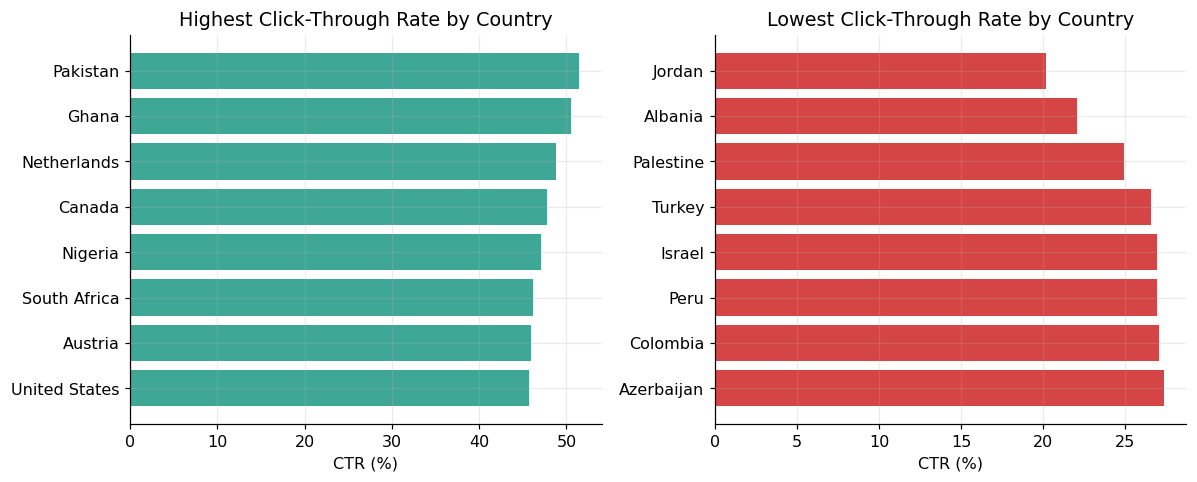

In [14]:
country_events["CTR"] = country_events["click"] / country_events["pageview"]
qualified = country_events[country_events["pageview"] > 200]

top_ctr = qualified.sort_values("CTR", ascending=False).head(8)
bot_ctr = qualified.sort_values("CTR", ascending=True).head(8)
print("Highest CTR countries:\n", top_ctr[["pageview", "click", "CTR"]])
print("\nLowest CTR countries:\n", bot_ctr[["pageview", "click", "CTR"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(top_ctr.sort_values("CTR").index, top_ctr.sort_values("CTR")["CTR"]*100, color="#3FA796")
axes[0].set_title("Highest Click-Through Rate by Country")
axes[0].set_xlabel("CTR (%)")
axes[1].barh(bot_ctr.sort_values("CTR", ascending=False).index, bot_ctr.sort_values("CTR", ascending=False)["CTR"]*100, color="#D64545")
axes[1].set_title("Lowest Click-Through Rate by Country")
axes[1].set_xlabel("CTR (%)")
plt.tight_layout()
plt.show()


**Finding:** click-through quality varies widely and doesn't track with volume — Pakistan has the highest CTR (51.5%) among high-volume countries, while Saudi Arabia, despite having the most total traffic, converts at a below-average 32.9%. Jordan, Albania, and Palestine convert lowest (20–25%), suggesting their traffic may be lower-intent or driven by a different, less targeted source.

city
Jeddah         22791
Riyadh         17454
Hyderabad       3682
Dammam          3276
Erbil           3105
Kuwait City     3010
Lucknow         2808
Muscat          2717
Delhi           2567
Jaipur          2531
Name: count, dtype: int64


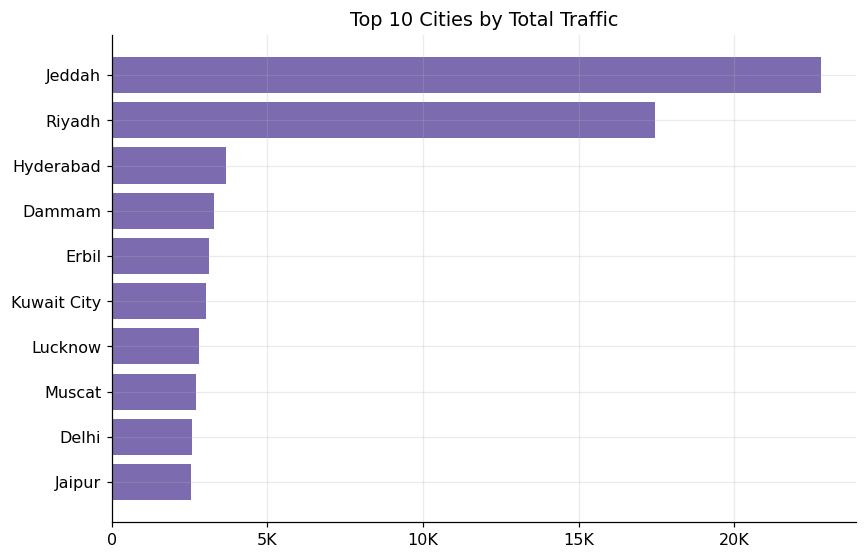

In [15]:
top_cities = df[df["city"] != "Unknown"]["city"].value_counts().head(10)
print(top_cities)

fig, ax = plt.subplots(figsize=(8, 5.2))
plot_data = top_cities.sort_values()
ax.barh(plot_data.index, plot_data.values, color="#7C6BAF")
ax.set_title("Top 10 Cities by Total Traffic")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(k_fmt))
plt.tight_layout()
plt.show()


**Finding:** Jeddah and Riyadh (both Saudi Arabia) are the two largest single cities by far, together exceeding the next 8 cities combined — confirming that Saudi Arabia's traffic volume is concentrated in a couple of major metro areas rather than spread nationally.

## 8. Content Performance (Artists, Tracks, Links)

artist
Tesher                                                          40841
Anne-Marie                                                      10650
Tundra Beats                                                     9751
Surf Mesa, Emilee                                                7533
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna     5512
Reyanna Maria                                                    5434
Shawn Mendes, Tainy                                              5409
50 Cent, Olivia                                                  5367
Roddy Ricch                                                      5093
Olivia Rodrigo                                                   4115
dtype: int64


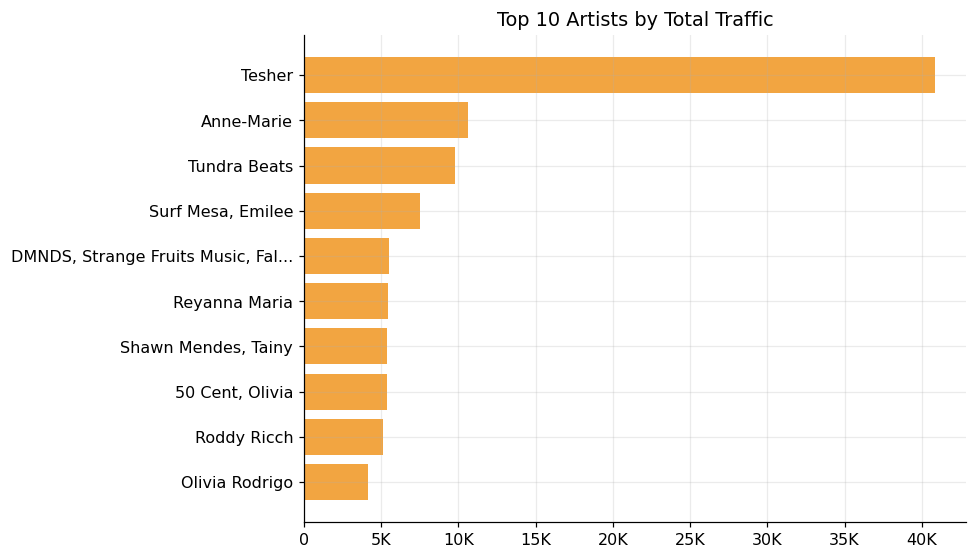

In [16]:
top_artists = df.groupby("artist").size().sort_values(ascending=False).head(10)
print(top_artists)

fig, ax = plt.subplots(figsize=(9, 5.2))
plot_data = top_artists.sort_values()
ax.barh([a if len(a) < 35 else a[:32]+"..." for a in plot_data.index], plot_data.values, color="#F2A541")
ax.set_title("Top 10 Artists by Total Traffic")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(k_fmt))
plt.tight_layout()
plt.show()


**Finding:** Tesher's "Jalebi Baby" alone drove 40,841 events — 18% of all traffic in the dataset from a single track, nearly 4x the second-place artist (Anne-Marie). This single link is disproportionately important to overall traffic health.

event                         pageview  click  total    CTR
Jalebi Baby                      25175   9692  40841  0.385
Beautiful                         6600   2109  10314  0.320
Beautiful Day                     5981   2198   9750  0.367
ily (i love you baby) (feat.      4303   1429   6733  0.332
Calabria (feat. Lujavo & Nit      3354   1500   5512  0.447
So Pretty                         3531   1186   5434  0.336
Candy Shop                        3407   1111   5367  0.326
Summer of Love (Shawn Mendes      3299   1353   5352  0.410
Late At Night                     3039   1364   5036  0.449
Build a Bitch                     2440    827   3879  0.339


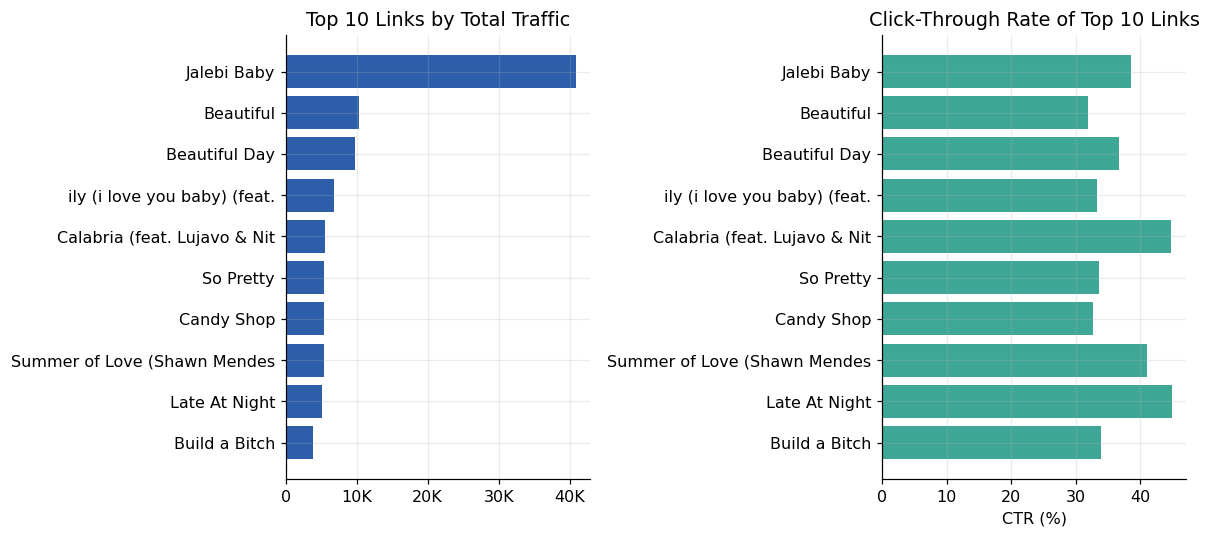

In [17]:
link_events = df.groupby("linkid")["event"].value_counts().unstack(fill_value=0)
link_events["total"] = link_events.sum(axis=1)
link_events["CTR"] = link_events["click"] / link_events["pageview"].replace(0, np.nan)
top_links = link_events.sort_values("total", ascending=False).head(10)

link_track = df.drop_duplicates("linkid").set_index("linkid")["track"]
top_links_named = top_links.copy()
top_links_named.index = [link_track.get(i, i)[:28] for i in top_links_named.index]
print(top_links_named[["pageview", "click", "total", "CTR"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
order = top_links_named.sort_values("total").index
axes[0].barh(order, top_links_named.loc[order, "total"], color="#2E5EAA")
axes[0].set_title("Top 10 Links by Total Traffic")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(k_fmt))
axes[1].barh(order, top_links_named.loc[order, "CTR"]*100, color="#3FA796")
axes[1].set_title("Click-Through Rate of Top 10 Links")
axes[1].set_xlabel("CTR (%)")
plt.tight_layout()
plt.show()


**Finding:** among the top 10 links by volume, CTR ranges from 32.6% to 44.9% — a meaningful spread even among already-popular content, meaning link page design/placement (not just the song itself) likely affects conversion.

## 9. Key Findings & Recommendations for Alfido Tech

### Key Findings
1. **Total traffic declined 13.9% across the one-week window** — pageviews and clicks fell in lockstep while previews stayed flat, pointing to a broad traffic decline rather than a change in on-page visitor behavior.
2. **Overall click-through rate is a strong 39.2%** of pageviews, but only 20.1% of visitors preview first — most conversions come from visitors who already know what they want, suggesting traffic is largely referral/share-driven rather than discovery-driven.
3. **Traffic is geographically concentrated** — Saudi Arabia and India together account for ~40% of all traffic, and within Saudi Arabia, two cities (Jeddah, Riyadh) dominate.
4. **Click-through quality doesn't track with volume** — Saudi Arabia has the most traffic but a below-average 32.9% CTR, while smaller markets like Pakistan (51.5%) and Canada (47.8%) convert far better.
5. **Traffic is highly concentrated in a single piece of content** — one track ("Jalebi Baby") drives 18% of all traffic, meaning overall traffic health is unusually dependent on one link's continued popularity.

### 5 Actionable Recommendations
1. **Investigate the cause of the 13.9% weekly decline** — determine whether it's the natural cooldown of a viral moment (tied to the top track) or a broader external factor (e.g. a promotional campaign ending), so Alfido Tech can plan for it rather than be surprised by it.
2. **Prioritize high-CTR, currently-smaller markets for growth investment** — Pakistan, Canada, Netherlands, and Nigeria convert well above average; increasing traffic acquisition there is likely more efficient than pushing further into already-saturated, lower-CTR Saudi Arabia.
3. **Diagnose why Saudi Arabia's CTR lags its traffic volume** — with the most visitors but a below-average conversion rate, even a modest CTR improvement there would yield an outsized number of additional clicks.
4. **Reduce dependency on a single top track** — actively cross-promote other artists/tracks on high-traffic pages (e.g. "you might also like") so a future decline in one song's popularity doesn't disproportionately hit total traffic.
5. **Study what the highest-CTR links among top content are doing differently** — since CTR varies from 32.6% to 44.9% even among the top 10 links, identifying and replicating those page/placement patterns across other links could lift conversion broadly.
